**Name** : Abhi Mondal     
**Roll No** : 22MS075

In [1]:
# pakages
import numpy as np
import matplotlib.pyplot as plt
from numba import njit              # used for fast compilation (for install run "pip install numba")

In [3]:
@njit
# function to perform the Moran Process
# input : (population size, mutation type 0 -> 1, fitness of type 0, fitness of type 1, initial fraction of type 0,max generation, windows size, tolerance)
# output: (frequency of type 0, frequecny of type 1)
def simulate_evolution_converge(N, u, f0, f1, init_frac_0, max_gen=3000, window=500, tol=0.005):

    norm_f0 = f0 / (f0 + f1)
    norm_f1 = f1 / (f0 + f1)

    # population 
    pop = np.ones(N, dtype=np.int32)
    init_0_count = int(N * init_frac_0)
    pop[:init_0_count] = 0

    freq0_history = np.zeros(max_gen)
    freq1_history = np.zeros(max_gen)

    mutated_pop = np.empty(N, dtype=np.int32)
    new_pop = np.empty(N, dtype=np.int32)

    # counter
    gen = 0
    while gen < max_gen:
        # record current frequencies
        count_0 = 0
        for i in range(N):
            if pop[i] == 0:
                count_0 += 1
        
        freq0_history[gen] = count_0 / N
        freq1_history[gen] = 1.0 - freq0_history[gen]

        # check for convergence (Equilibrium)
        # comparison between two window of data 
        if gen >= 2 * window:
            # average of the most recent window
            avg_current = np.mean(freq0_history[gen-window : gen])
            # average of the window right before it
            avg_prev = np.mean(freq0_history[gen-2*window : gen-window])
            
            # if the moving average has stopped changing significantly, we break
            if abs(avg_current - avg_prev) < tol:
                gen += 1
                break

        # mutation step
        for i in range(N):
            if pop[i] == 0:
                if np.random.rand() < u:
                    mutated_pop[i] = 1          # mutation 0 -> 1
                else:
                    mutated_pop[i] = 0          # no mutation
            else:
                mutated_pop[i] = 1              # mutation 1 -> 0 is 0

        # selection step with Wright-Fisher method
        filled = 0
        while filled < N:
            candidate_idx = np.random.randint(N)
            candidate = mutated_pop[candidate_idx]
            
            r = np.random.rand()
            if candidate == 0 and r <= norm_f0:     # fitness compare for type 0
                new_pop[filled] = 0
                filled += 1
            elif candidate == 1 and r <= norm_f1:   # fitness compare for type 1
                new_pop[filled] = 1
                filled += 1
                
        # update the population with new one 
        pop[:] = new_pop[:]
        # increase the gen number
        gen += 1
        
    # return the portion of the array that was filled up to the point of convergence
    return freq0_history[:gen], freq1_history[:gen]

Case (i) converged in 1341 generations.
Case (ii) converged in 1005 generations.
Case (iii) converged in 1402 generations.


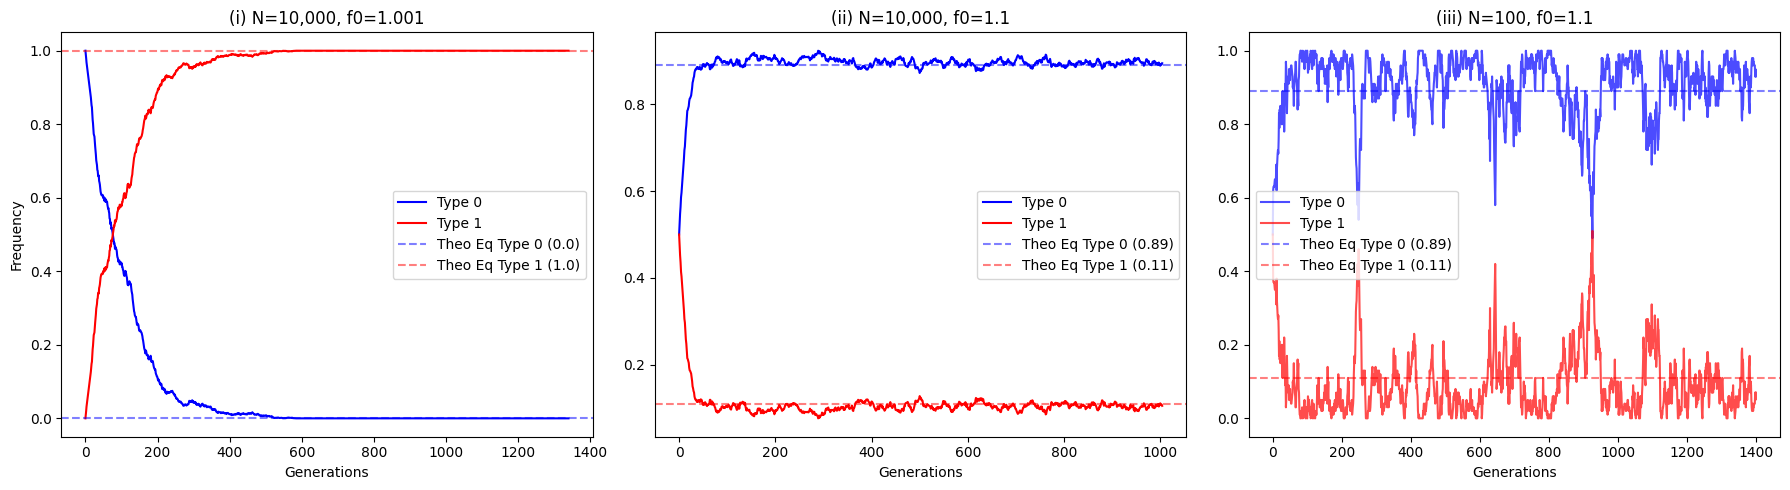

In [4]:
# (i) N=10000, initially all type 0, u=0.01, f0=1.001, f1=1
f0_1, f1_1 = simulate_evolution_converge(N=10000, u=0.01, f0=1.001, f1=1.0, init_frac_0=1.0)
print(f"Case (i) converged in {len(f0_1)} generations.")

# (ii) N=10000, initially half type 0, u=0.01, f0=1.1, f1=1
f0_2, f1_2 = simulate_evolution_converge(N=10000, u=0.01, f0=1.1, f1=1.0, init_frac_0=0.5)
print(f"Case (ii) converged in {len(f0_2)} generations.")

# (iii) N=100, initially half type 0, u=0.01, f0=1.1, f1=1
f0_3, f1_3 = simulate_evolution_converge(N=100, u=0.01, f0=1.1, f1=1.0, init_frac_0=0.5, tol=0.01)
print(f"Case (iii) converged in {len(f0_3)} generations.")

# plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot (i)
axes[0].plot(np.arange(len(f0_1)), f0_1, label="Type 0", color="blue")
axes[0].plot(np.arange(len(f1_1)), f1_1, label="Type 1", color="red")
axes[0].set_title("(i) N=10,000, f0=1.001")
axes[0].set_xlabel("Generations")
axes[0].set_ylabel("Frequency")
axes[0].axhline(y=0, color='blue', linestyle='--', alpha=0.5, label="Theo Eq Type 0 (0.0)")
axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.5, label="Theo Eq Type 1 (1.0)")
axes[0].legend()

# Plot (ii)
axes[1].plot(np.arange(len(f0_2)), f0_2, label="Type 0", color="blue")
axes[1].plot(np.arange(len(f1_2)), f1_2, label="Type 1", color="red")
axes[1].set_title("(ii) N=10,000, f0=1.1")
axes[1].set_xlabel("Generations")
axes[1].axhline(y=0.89, color='blue', linestyle='--', alpha=0.5, label="Theo Eq Type 0 (0.89)")
axes[1].axhline(y=0.11, color='red', linestyle='--', alpha=0.5, label="Theo Eq Type 1 (0.11)")
axes[1].legend()

# Plot (iii)
axes[2].plot(np.arange(len(f0_3)), f0_3, label="Type 0", color="blue", alpha=0.7)
axes[2].plot(np.arange(len(f1_3)), f1_3, label="Type 1", color="red", alpha=0.7)
axes[2].set_title("(iii) N=100, f0=1.1")
axes[2].set_xlabel("Generations")
axes[2].axhline(y=0.89, color='blue', linestyle='--', alpha=0.5, label="Theo Eq Type 0 (0.89)")
axes[2].axhline(y=0.11, color='red', linestyle='--', alpha=0.5, label="Theo Eq Type 1 (0.11)")
axes[2].legend()

plt.tight_layout()
plt.show()